현재 XGBoost 분석은 최종 K-Means 위험군 라벨이 확정되기 전이므로, 코드 구조 확인을 위해 임시 규칙 기반 target을 생성하여 테스트하였다.  
추후 팀원의 최종 K-Means 결과에서 위험군 라벨이 확정되면 해당 라벨을 target으로 교체하여 XGBoost를 재실행할 예정이다.

In [3]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.stats import kruskal
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

# Windows에서는 Malgun Gothic이 보통 잘 동작합니다.
# Mac / Linux에서는 다른 한글 폰트로 바꿔야 할 수 있습니다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
BASE_DIR = Path("../data").resolve()

real_estate_path = BASE_DIR / "real_estate_pressure_kmeans_ready.csv"

real_estate = pd.read_csv(real_estate_path, encoding="utf-8-sig")

print("파일 경로:", real_estate_path)
print("데이터 크기:", real_estate.shape)

display(real_estate.head())
print(real_estate.columns.tolist())

파일 경로: C:\Users\wlfbs\final_project\data\real_estate_pressure_kmeans_ready.csv
데이터 크기: (150, 18)


,행정동,period,avg_land_price,land_price_growth_rate,transaction_count,transaction_growth_rate,transaction_log_growth,transaction_new_activity_flag,z_land_price_growth,z_transaction_growth,z_transaction_log_growth,real_estate_pressure_index,real_estate_pressure_index_100,real_estate_pressure_level,kmeans_land_feature,kmeans_transaction_feature,real_estate_cluster,real_estate_cluster_name
0,고등동,2023,2.973713e+06,NaN,102.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,고등동,2024,3.052398e+06,2.646013,35.0,-65.686275,-1.051210,0.0,-0.110866,-0.940790,-1.672357,-0.525828,14.599109,하,-0.110866,-0.940790,0.0,상승-거래정체형
2,고등동,2025,3.083884e+06,1.031506,44.0,25.714286,0.223144,0.0,-1.640093,-0.192608,0.113267,-0.916351,6.495705,하,-1.640093,-0.192608,1.0,하락-거래위축형
3,구미1동,2023,4.982715e+06,NaN,73.5,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,구미1동,2024,5.108031e+06,2.515020,307.0,317.687075,1.419301,0.0,-0.234941,2.197407,1.789323,0.981233,45.870885,상,-0.234941,2.197407,2.0,상승-거래정체형


['행정동', 'period', 'avg_land_price', 'land_price_growth_rate', 'transaction_count', 'transaction_growth_rate', 'transaction_log_growth', 'transaction_new_activity_flag', 'z_land_price_growth', 'z_transaction_growth', 'z_transaction_log_growth', 'real_estate_pressure_index', 'real_estate_pressure_index_100', 'real_estate_pressure_level', 'kmeans_land_feature', 'kmeans_transaction_feature', 'real_estate_cluster', 'real_estate_cluster_name']


In [5]:
# =========================================================
# 2단계. 2025년 부동산 지표만 추출
# =========================================================

real_estate_2025 = real_estate[real_estate["period"] == 2025].copy()

real_estate_2025 = real_estate_2025[
    [
        "행정동",
        "period",
        "avg_land_price",
        "land_price_growth_rate",
        "transaction_count",
        "transaction_growth_rate",
        "transaction_log_growth",
        "real_estate_pressure_index_100",
        "real_estate_pressure_level",
        "real_estate_cluster_name"
    ]
].copy()

real_estate_2025 = real_estate_2025.rename(columns={
    "행정동": "adm_dong_nm",
    "period": "base_year",
    "avg_land_price": "avg_land_price_2025",
    "land_price_growth_rate": "land_price_growth_2025",
    "transaction_count": "transaction_count_2025",
    "transaction_growth_rate": "transaction_growth_2025",
    "transaction_log_growth": "transaction_log_growth_2025",
    "real_estate_pressure_index_100": "real_estate_pressure_index_100_2025",
    "real_estate_pressure_level": "real_estate_pressure_level_2025",
    "real_estate_cluster_name": "real_estate_cluster_name_2025"
})

print("2025년 부동산 데이터 크기:", real_estate_2025.shape)
display(real_estate_2025.head())

2025년 부동산 데이터 크기: (50, 10)


,adm_dong_nm,base_year,avg_land_price_2025,land_price_growth_2025,transaction_count_2025,transaction_growth_2025,transaction_log_growth_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025
2,고등동,2025,3.083884e+06,1.031506,44.0,25.714286,0.223144,6.495705,하,하락-거래위축형
5,구미1동,2025,5.294566e+06,3.651796,320.5,4.397394,0.042898,30.435044,중상,상승-거래정체형
8,구미동,2025,6.501922e+06,3.326565,47.5,-33.098592,-0.395102,24.054533,중하,상승-거래정체형
11,금곡동,2025,4.257467e+06,3.944351,143.0,-17.816092,-0.194973,31.423456,중상,상승-거래정체형
14,금광1동,2025,5.205786e+06,2.671988,11.5,-46.511628,-0.587787,16.482825,중하,상승-거래정체형


2025년도만 해서 행정동 50행 feature table 생성 완료

In [6]:
# =========================================================
# 3단계. 2025년 부동산 지표 결측 확인
# =========================================================

print("2025년 부동산 데이터 크기:", real_estate_2025.shape)

print("\n결측치 개수:")
display(real_estate_2025.isna().sum())

print("\n결측이 있는 행:")
display(real_estate_2025[real_estate_2025.isna().any(axis=1)])

2025년 부동산 데이터 크기: (50, 10)

결측치 개수:


adm_dong_nm                            0
base_year                              0
avg_land_price_2025                    0
land_price_growth_2025                 0
transaction_count_2025                 0
transaction_growth_2025                0
transaction_log_growth_2025            0
real_estate_pressure_index_100_2025    0
real_estate_pressure_level_2025        0
real_estate_cluster_name_2025          0
dtype: int64


결측이 있는 행:


,adm_dong_nm,base_year,avg_land_price_2025,land_price_growth_2025,transaction_count_2025,transaction_growth_2025,transaction_log_growth_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025


In [7]:
# =========================================================
# 4단계. 부동산 후보 변수 상관관계 확인
# =========================================================

real_estate_candidate_features = [
    "land_price_growth_2025",
    "transaction_log_growth_2025",
    "real_estate_pressure_index_100_2025"
]

print("부동산 후보 변수:")
print(real_estate_candidate_features)

print("\n기본 통계:")
display(real_estate_2025[real_estate_candidate_features].describe().T)

print("\n상관관계:")
display(real_estate_2025[real_estate_candidate_features].corr().round(3))

부동산 후보 변수:
['land_price_growth_2025', 'transaction_log_growth_2025', 'real_estate_pressure_index_100_2025']

기본 통계:


,count,mean,std,min,25%,50%,75%,max
land_price_growth_2025,50.0,3.347468,0.723132,1.031506,2.850742,3.125953,3.799192,5.098972
transaction_log_growth_2025,50.0,-0.011670,0.792723,-3.332205,-0.241162,0.109908,0.364906,2.166453
real_estate_pressure_index_100_2025,50.0,30.112989,14.005584,6.495705,19.991150,26.821807,35.926679,100.000000



상관관계:


,land_price_growth_2025,transaction_log_growth_2025,real_estate_pressure_index_100_2025
land_price_growth_2025,1.000,-0.091,0.538
transaction_log_growth_2025,-0.091,1.000,0.570
real_estate_pressure_index_100_2025,0.538,0.570,1.000


상관관계 확인 결과 부동산 데이터에서는 land_price_growth_2025,transaction_log_growth_2025 2개로 가져가는게 좋을거 같음

| 변수                            | 의미        |
| ----------------------------- | --------- |
| `land_price_growth_2025`      | 가격 압박     |
| `transaction_log_growth_2025` | 거래 활성도 변화 |


In [8]:
# =========================================================
# 5단계. 부동산 최종 feature 저장
# =========================================================

real_estate_final_features = [
    "land_price_growth_2025",
    "transaction_log_growth_2025"
]

real_estate_final = real_estate_2025[
    [
        "adm_dong_nm",
        "base_year",
        "avg_land_price_2025",
        "transaction_count_2025",
        "real_estate_pressure_index_100_2025",
        "real_estate_pressure_level_2025",
        "real_estate_cluster_name_2025"
    ]
    + real_estate_final_features
].copy()

save_path = BASE_DIR / "real_estate_final_features_2vars.csv"

real_estate_final.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)
print(real_estate_final.shape)
display(real_estate_final.head())

저장 완료: C:\Users\wlfbs\final_project\data\real_estate_final_features_2vars.csv
(50, 9)


,adm_dong_nm,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025
2,고등동,2025,3.083884e+06,44.0,6.495705,하,하락-거래위축형,1.031506,0.223144
5,구미1동,2025,5.294566e+06,320.5,30.435044,중상,상승-거래정체형,3.651796,0.042898
8,구미동,2025,6.501922e+06,47.5,24.054533,중하,상승-거래정체형,3.326565,-0.395102
11,금곡동,2025,4.257467e+06,143.0,31.423456,중상,상승-거래정체형,3.944351,-0.194973
14,금광1동,2025,5.205786e+06,11.5,16.482825,중하,상승-거래정체형,2.671988,-0.587787


In [9]:
# 피쳐만든 인구데이터랑 부동산데이터 합쳐보기
pop_df = pd.read_csv("../data/population_final_features_4vars.csv", encoding="utf-8-sig")
real_df = pd.read_csv("../data/real_estate_final_features_2vars.csv", encoding="utf-8-sig")

merged_df = pop_df.merge(
    real_df,
    on="adm_dong_nm",
    how="left"
)

print(merged_df.shape)
display(merged_df.head())
print(merged_df.isna().sum())

(50, 16)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823


adm_dong_cd                            0
adm_dong_nm                            0
gu                                     0
base_quarter                           0
floating_pop_recent4_mean_log          0
external_inflow_ratio                  0
external_inflow_slope_4q               0
floating_pop_yoy                       0
base_year                              0
avg_land_price_2025                    0
transaction_count_2025                 0
real_estate_pressure_index_100_2025    0
real_estate_pressure_level_2025        0
real_estate_cluster_name_2025          0
land_price_growth_2025                 0
transaction_log_growth_2025            0
dtype: int64


In [10]:
# 부동산 파일에서 행정동 중복 여부 확인
print(real_df["adm_dong_nm"].duplicated().sum())

# 신흥동 계열 확인
display(
    real_df[real_df["adm_dong_nm"].str.contains("신흥", na=False)]
)

0


,adm_dong_nm,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025
26,신흥1동,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.22739
27,신흥2동,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.22739
28,신흥3동,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.22739


공시지가/실거래가 데이터는 법정동 기준
신흥1동, 신흥2동, 신흥3동은 같은 법정동 신흥동 계열
→ 법정동 값을 행정동으로 매핑하면서 같은 값이 배정됨

부동산 데이터는 법정동 단위로 제공되어, 일부 행정동은 동일한 법정동 값을 공유한다.
따라서 공시지가 및 거래량 지표는 행정동 내부의 미세한 차이보다는 법정동 기반의 부동산 압박 수준으로 해석한다.

In [11]:
# 같은 부동산 지표를 공유하는 행정동 그룹 확인
same_real_estate_groups = (
    real_df
    .groupby([
        "avg_land_price_2025",
        "land_price_growth_2025",
        "transaction_log_growth_2025"
    ])["adm_dong_nm"]
    .apply(list)
    .reset_index()
)

same_real_estate_groups["dong_count"] = same_real_estate_groups["adm_dong_nm"].apply(len)

display(
    same_real_estate_groups
    .sort_values("dong_count", ascending=False)
    .head(10)
)

,avg_land_price_2025,land_price_growth_2025,transaction_log_growth_2025,adm_dong_nm,dong_count
11,4.832634e+06,3.125953,0.150823,"[태평1동, 태평2동, 태평3동, 태평4동]",4
30,7.972175e+06,2.755530,-0.241162,"[정자1동, 정자2동, 정자3동, 정자동]",4
19,5.809309e+06,4.230717,0.227390,"[신흥1동, 신흥2동, 신흥3동]",3
18,5.726636e+06,2.850742,-1.370208,"[야탑1동, 야탑2동, 야탑3동]",3
7,4.094303e+06,2.584546,-0.136966,"[상대원1동, 상대원2동, 상대원3동]",3
31,8.576315e+06,3.108075,0.154151,"[수내1동, 수내2동, 수내3동]",3
17,5.466318e+06,3.992248,0.615186,"[수진1동, 수진2동]",2
10,4.503143e+06,2.998755,0.575364,"[은행1동, 은행2동]",2
14,5.205786e+06,2.671988,-0.587787,"[금광1동, 금광2동]",2
0,2.890668e+06,2.731970,0.597837,[신촌동],1


부동산 데이터는 법정동 기준으로 행정동 단위 분석에 맞추기 위해 매핑했다 그러므로 일부 행정동 1동,2동,3동은 법정동 기반 부동산 지표를 공유하여 부동산 압박으로 해석한다.

In [12]:
merged_df = merged_df.copy()

lower = merged_df["floating_pop_yoy"].quantile(0.05)
upper = merged_df["floating_pop_yoy"].quantile(0.95)

merged_df["floating_pop_yoy_clip"] = merged_df["floating_pop_yoy"].clip(lower, upper)

save_path = BASE_DIR / "xgboost_base_population_real_estate.csv"

merged_df.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)
print(merged_df.shape)
display(merged_df.head())

저장 완료: C:\Users\wlfbs\final_project\data\xgboost_base_population_real_estate.csv
(50, 17)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025,floating_pop_yoy_clip
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,-2.368723
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,6.025696
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,1.666822
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,0.769564
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,-6.018743


상권 활력도 가져오기

In [13]:
BASE_DIR = Path("../data/output").resolve()

dong_feature_path = BASE_DIR / "dong_feature_table_with_clusters.csv"

dong_feature = pd.read_csv(dong_feature_path, encoding="utf-8-sig")

print(dong_feature.shape)
print(dong_feature.columns.tolist())

display(dong_feature.head())

(50, 101)
['adm_dong_cd', 'adm_dong_nm', 'gu', 'sales_amt_base', 'sales_cnt_base', 'avg_ticket_base', 'new_corp_cnt_base', 'store_mer_cnt_base', 'franchise_cnt_base', 'open_cnt_base', 'close_cnt_base', 'open_rate_base', 'close_rate_base', 'franchise_ratio_base', 'industry_diversity_H_base', 'survival_rate_1y_base', 'floating_pop_base', 'external_inflow_base', 'stay_time_weighted_base', 'stay_time_cnt_base', '전입_총인원_base', '전입_고소득층_인원_base', '전입_고소득층_비율_base', '전입_소득수준_가중평균_분기_base', 'transport_total_cnt_base', 'bus_board_cnt_base', 'bus_alight_cnt_base', 'bus_total_cnt_base', 'sales_amt_recent', 'sales_cnt_recent', 'avg_ticket_recent', 'new_corp_cnt_recent', 'store_mer_cnt_recent', 'franchise_cnt_recent', 'open_cnt_recent', 'close_cnt_recent', 'open_rate_recent', 'close_rate_recent', 'franchise_ratio_recent', 'industry_diversity_H_recent', 'survival_rate_1y_recent', 'floating_pop_recent', 'external_inflow_recent', 'stay_time_weighted_recent', 'stay_time_cnt_recent', '전입_총인원_recent', '전

,adm_dong_cd,adm_dong_nm,gu,sales_amt_base,sales_cnt_base,avg_ticket_base,new_corp_cnt_base,store_mer_cnt_base,franchise_cnt_base,open_cnt_base,close_cnt_base,open_rate_base,close_rate_base,franchise_ratio_base,industry_diversity_H_base,survival_rate_1y_base,floating_pop_base,external_inflow_base,stay_time_weighted_base,stay_time_cnt_base,전입_총인원_base,전입_고소득층_인원_base,전입_고소득층_비율_base,전입_소득수준_가중평균_분기_base,transport_total_cnt_base,bus_board_cnt_base,bus_alight_cnt_base,bus_total_cnt_base,sales_amt_recent,sales_cnt_recent,avg_ticket_recent,new_corp_cnt_recent,store_mer_cnt_recent,franchise_cnt_recent,open_cnt_recent,close_cnt_recent,open_rate_recent,close_rate_recent,franchise_ratio_recent,industry_diversity_H_recent,survival_rate_1y_recent,floating_pop_recent,external_inflow_recent,stay_time_weighted_recent,stay_time_cnt_recent,전입_총인원_recent,전입_고소득층_인원_recent,전입_고소득층_비율_recent,전입_소득수준_가중평균_분기_recent,transport_total_cnt_recent,bus_board_cnt_recent,bus_alight_cnt_recent,bus_total_cnt_recent,new_corp_cnt_recent4_mean,new_corp_cnt_recent4_change,new_corp_cnt_recent4_slope,franchise_ratio_recent4_mean,franchise_ratio_recent4_change,franchise_ratio_recent4_slope,external_inflow_recent4_mean,external_inflow_recent4_change,external_inflow_recent4_slope,open_rate_recent4_mean,open_rate_recent4_change,open_rate_recent4_slope,close_rate_recent4_mean,close_rate_recent4_change,close_rate_recent4_slope,store_mer_cnt_recent4_mean,store_mer_cnt_recent4_change,store_mer_cnt_recent4_slope,mkt_vital_local,mkt_vital_balance,external_inflow_log_recent,sales_amt_growth,sales_cnt_growth,avg_ticket_growth,new_corp_growth,store_mer_growth,floating_pop_growth,external_inflow_growth,in_migration_growth,transport_total_growth,bus_total_growth,franchise_ratio_change,industry_diversity_change,stay_time_weighted_change,high_income_inflow_ratio_change,income_level_change,open_rate_recent_final,close_rate_recent_final,survival_rate_recent,cluster_basic,commerce_score,population_score,transport_score,commerce_score_weighted,population_score_weighted,transport_score_weighted,gentrification_weighted_score,cluster_weighted
0,41131510,신흥1동,수정구,2.597995e+10,1069346.75,24323.925593,0.5,4767.25,239.00,60.50,74.75,1.270262,1.570053,5.014419,3.496858,NaN,8.147074e+05,146195.9825,235.260326,5.899107e+05,1883.5,326.25,0.173213,3107.583842,5.074635e+05,407380.00,390754.0,798134.00,2.342966e+10,954567.0,24557.458763,1.00,5249.25,265.25,52.00,59.25,0.990485,1.129590,5.055550,3.496941,93.680225,7.442924e+05,2.082935e+05,265.860421,7.443059e+05,1688.00,312.00,0.184728,3288.715420,7.573043e+05,397576.50,435188.00,832764.50,1.00,2.0,6.000000e-01,5.055550,-0.538261,-0.196598,2.082935e+05,12074.56,3694.013,0.990485,0.099101,-0.000443,1.129590,0.207117,0.037912,5249.25,101.0,47.1,-0.417854,-0.004179,12.246708,-0.098164,-0.107336,0.009601,1.000000,0.101107,-0.086430,0.424755,-0.103796,0.492333,0.043389,0.041131,0.000083,30.600095,0.011515,181.131578,0.990485,1.129590,93.680225,0,-0.269770,-0.604970,0.071212,-0.134885,-0.216061,0.010173,-0.340772,1
1,41131520,신흥2동,수정구,3.217763e+10,1240452.25,25957.046856,1.5,3494.25,192.00,46.50,35.50,1.328279,1.015449,5.493760,3.652938,NaN,2.123426e+06,628037.1400,232.430485,1.810001e+06,4621.5,1623.50,0.350821,4263.656710,1.735510e+06,334647.00,304791.0,639438.00,3.087468e+10,1288105.5,24004.595866,2.25,4106.75,279.50,62.50,46.50,1.536592,1.135723,6.810407,3.688897,91.155468,3.098554e+06,1.060452e+06,253.292309,3.098474e+06,11194.00,4008.75,0.356109,4485.074866,3.109814e+06,466454.25,432154.75,898609.00,2.25,4.0,1.500000e+00,6.810407,-0.271798,-0.104181,1.060452e+06,83399.25,33019.428,1.536592,-0.792823,-0.321809,1.135723,-0.265845,-0.089187,4106.75,330.0,125.5,-0.070241,-0.000702,13.874207,-0.040493,0.038416,-0.075219,0.500000,0.175288,0.459224,0.688518,1.422157,0.791873,0.405311,1.316647,0.035958,20.861824,0.005288,221.418156,1.536592,1.135723,91.155468,0,0.433710,0.677781,0.741115,0.216855,0.242065,0.105874,0.564793,0
2,41131530,신흥3동,수정구,3.724727e+

In [14]:
# 상권활력도 변수만 추출
commerce_vital = dong_feature[
    [
        "adm_dong_cd",
        "adm_dong_nm",
        "gu",
        "mkt_vital_local",
        "mkt_vital_balance"
    ]
].copy()

print(commerce_vital.shape)
display(commerce_vital.head())

print("결측치 확인")
display(commerce_vital.isna().sum())

(50, 5)


,adm_dong_cd,adm_dong_nm,gu,mkt_vital_local,mkt_vital_balance
0,41131510,신흥1동,수정구,-0.417854,-0.004179
1,41131520,신흥2동,수정구,-0.070241,-0.000702
2,41131530,신흥3동,수정구,-0.033812,-0.000338
3,41131540,태평1동,수정구,-0.267876,-0.002679
4,41131550,태평2동,수정구,-0.120048,-0.001200


결측치 확인


adm_dong_cd          0
adm_dong_nm          0
gu                   0
mkt_vital_local      0
mkt_vital_balance    0
dtype: int64

In [15]:
# 기존 xgboost용 데이터 파일에 붙이기
BASE_DIR = Path("../data").resolve()

# 1. 기존 인구+부동산 베이스 파일 불러오기
xgb_base_path = BASE_DIR / "xgboost_base_population_real_estate.csv"
xgb_base = pd.read_csv(xgb_base_path, encoding="utf-8-sig")

print("xgb_base:", xgb_base.shape)
display(xgb_base.head())

xgb_base:

 (50, 17)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025,floating_pop_yoy_clip
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,-2.368723
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,6.025696
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,1.666822
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,0.769564
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,-6.018743


In [16]:
commerce_vital = dong_feature[
    [
        "adm_dong_cd",
        "adm_dong_nm",
        "gu",
        "mkt_vital_balance"
    ]
].copy()

commerce_vital = commerce_vital.rename(columns={
    "mkt_vital_balance": "mkt_balance_recent"
})

print("commerce_vital:", commerce_vital.shape)
display(commerce_vital.head())

commerce_vital: (50, 4)


,adm_dong_cd,adm_dong_nm,gu,mkt_balance_recent
0,41131510,신흥1동,수정구,-0.004179
1,41131520,신흥2동,수정구,-0.000702
2,41131530,신흥3동,수정구,-0.000338
3,41131540,태평1동,수정구,-0.002679
4,41131550,태평2동,수정구,-0.001200


In [17]:
xgb_with_commerce = xgb_base.merge(
    commerce_vital,
    on=["adm_dong_cd", "adm_dong_nm", "gu"],
    how="left"
)

print("합친 데이터 크기:", xgb_with_commerce.shape)

display(xgb_with_commerce.head())

print("결측치 확인:")
display(xgb_with_commerce.isna().sum())

합친 데이터 크기: (50, 18)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025,floating_pop_yoy_clip,mkt_balance_recent
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,-2.368723,-0.004179
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,6.025696,-0.000702
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,1.666822,-0.000338
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,0.769564,-0.002679
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,-6.018743,-0.001200


결측치 확인:


adm_dong_cd                            0
adm_dong_nm                            0
gu                                     0
base_quarter                           0
floating_pop_recent4_mean_log          0
external_inflow_ratio                  0
external_inflow_slope_4q               0
floating_pop_yoy                       0
base_year                              0
avg_land_price_2025                    0
transaction_count_2025                 0
real_estate_pressure_index_100_2025    0
real_estate_pressure_level_2025        0
real_estate_cluster_name_2025          0
land_price_growth_2025                 0
transaction_log_growth_2025            0
floating_pop_yoy_clip                  0
mkt_balance_recent                     0
dtype: int64

In [18]:
save_path = BASE_DIR / "xgboost_base_population_real_estate_commerce.csv"

xgb_with_commerce.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)
print(xgb_with_commerce.shape)

저장 완료: C:\Users\wlfbs\final_project\data\xgboost_base_population_real_estate_commerce.csv
(50, 18)


In [19]:
commerce_more = dong_feature[
    [
        "adm_dong_cd",
        "adm_dong_nm",
        "gu",
        "franchise_ratio_recent",
        "franchise_ratio_change",
        "sales_amt_recent",
        "sales_cnt_growth",
        "new_corp_growth",
        "new_corp_cnt_recent4_slope"
    ]
].copy()

# 매출액 log 변수만 새로 생성
commerce_more["sales_amt_recent_log"] = np.log1p(commerce_more["sales_amt_recent"])

# 원 매출액은 너무 스케일이 크니까 일단 제거
commerce_more = commerce_more.drop(columns=["sales_amt_recent"])

display(commerce_more.head())
display(commerce_more.isna().sum())

,adm_dong_cd,adm_dong_nm,gu,franchise_ratio_recent,franchise_ratio_change,sales_cnt_growth,new_corp_growth,new_corp_cnt_recent4_slope,sales_amt_recent_log
0,41131510,신흥1동,수정구,5.055550,0.041131,-0.107336,1.000000,6.000000e-01,23.877269
1,41131520,신흥2동,수정구,6.810407,1.316647,0.038416,0.500000,1.500000e+00,24.153202
2,41131530,신흥3동,수정구,5.920700,-0.193776,-0.015850,0.000000,-7.107906e-17,24.347769
3,41131540,태평1동,수정구,5.300565,-0.921823,-0.091937,1.750000,-1.300000e+00,23.761095
4,41131550,태평2동,수정구,4.217316,-0.022637,-0.021080,-0.666667,-7.074641e-17,23.746867


adm_dong_cd                   0
adm_dong_nm                   0
gu                            0
franchise_ratio_recent        0
franchise_ratio_change        0
sales_cnt_growth              0
new_corp_growth               1
new_corp_cnt_recent4_slope    0
sales_amt_recent_log          0
dtype: int64

In [20]:
commerce_more[commerce_more["new_corp_growth"].isna()]

,adm_dong_cd,adm_dong_nm,gu,franchise_ratio_recent,franchise_ratio_change,sales_cnt_growth,new_corp_growth,new_corp_cnt_recent4_slope,sales_amt_recent_log
10,41131600,산성동,수정구,7.897274,1.519468,0.607287,NaN,-0.2,23.093803


In [21]:
# new_corp_growth 결측 1개 중앙값 대체
median_new_corp_growth = commerce_more["new_corp_growth"].median()

commerce_more["new_corp_growth"] = commerce_more["new_corp_growth"].fillna(
    median_new_corp_growth
)

print("new_corp_growth 중앙값:", median_new_corp_growth)

display(commerce_more[commerce_more["adm_dong_nm"] == "산성동"])
display(commerce_more.isna().sum())

new_corp_growth 중앙값: -0.1071428571428571


,adm_dong_cd,adm_dong_nm,gu,franchise_ratio_recent,franchise_ratio_change,sales_cnt_growth,new_corp_growth,new_corp_cnt_recent4_slope,sales_amt_recent_log
10,41131600,산성동,수정구,7.897274,1.519468,0.607287,-0.107143,-0.2,23.093803


adm_dong_cd                   0
adm_dong_nm                   0
gu                            0
franchise_ratio_recent        0
franchise_ratio_change        0
sales_cnt_growth              0
new_corp_growth               0
new_corp_cnt_recent4_slope    0
sales_amt_recent_log          0
dtype: int64

In [22]:
xgb_base = pd.read_csv(
    BASE_DIR / "xgboost_base_population_real_estate_commerce.csv",
    encoding="utf-8-sig"
)

xgb_full = xgb_base.merge(
    commerce_more,
    on=["adm_dong_cd", "adm_dong_nm", "gu"],
    how="left"
)

print("최종 병합 크기:", xgb_full.shape)

display(xgb_full.head())

print("결측치 확인:")
display(xgb_full.isna().sum())

최종 병합 크기: (50, 24)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025,floating_pop_yoy_clip,mkt_balance_recent,franchise_ratio_recent,franchise_ratio_change,sales_cnt_growth,new_corp_growth,new_corp_cnt_recent4_slope,sales_amt_recent_log
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,-2.368723,-0.004179,5.055550,0.041131,-0.107336,1.000000,6.000000e-01,23.877269
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,6.025696,-0.000702,6.810407,1.316647,0.038416,0.500000,1.500000e+00,24.153202
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,1.666822,-0.000338,5.920700,-0.193776,-0.015850,0.000000,-7.107906e-17,24.347769
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,0.769564,-0.002679,5.300565,-0.921823,-0.091937,1.750000,-1.300000e+00,23.761095
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,-6.018743,-0.001200,4.217316,-0.022637,-0.021080,-0.666667,-7.074641e-17,23.746867


결측치 확인:


adm_dong_cd                            0
adm_dong_nm                            0
gu                                     0
base_quarter                           0
floating_pop_recent4_mean_log          0
external_inflow_ratio                  0
external_inflow_slope_4q               0
floating_pop_yoy                       0
base_year                              0
avg_land_price_2025                    0
transaction_count_2025                 0
real_estate_pressure_index_100_2025    0
real_estate_pressure_level_2025        0
real_estate_cluster_name_2025          0
land_price_growth_2025                 0
transaction_log_growth_2025            0
floating_pop_yoy_clip                  0
mkt_balance_recent                     0
franchise_ratio_recent                 0
franchise_ratio_change                 0
sales_cnt_growth                       0
new_corp_growth                        0
new_corp_cnt_recent4_slope             0
sales_amt_recent_log                   0
dtype: int64

산성동의 `new_corp_growth`는 기준기간 신규기업 수 문제로 증가율 계산이 불가능하여 결측이 발생하였다.  
결측은 1개 행에 한정되어 있어, 상권 변수 전체의 중앙값으로 대체하였다.

In [23]:
save_path = BASE_DIR / "xgboost_feature_table_before_target.csv"

xgb_full.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)
print(xgb_full.shape)

저장 완료: C:\Users\wlfbs\final_project\data\xgboost_feature_table_before_target.csv
(50, 24)


인구, 부동산, 상권 담당 파일에서 필요한 행정동 단위 feature를 추출해 adm_dong_cd, adm_dong_nm, gu 기준으로 병합했고, 결측치 없는 50행짜리 XGBoost 입력 후보 테이블을 만들었다.

이제 테이블 생성했고 임시로 target 붙여서 최종 k-means나오면 교체하는걸로

# XGboost 실행

## 실행할때 쓰인 변수들

| 카테고리 | 변수명                             | 의미                            |
| ---- | ------------------------------- | ----------------------------- |
| 인구   | `floating_pop_recent4_mean_log` | 최근 4분기 유동인구 규모를 log 변환한 값     |
| 인구   | `external_inflow_ratio`         | 전체 유동인구 중 외부유입 인구 비중          |
| 인구   | `external_inflow_slope_4q`      | 최근 4분기 외부유입 인구 증가/감소 추세       |
| 인구   | `floating_pop_yoy_clip`         | 전년 동분기 대비 유동인구 변화율, 이상치 완화 적용 |
| 부동산  | `land_price_growth_2025`        | 2025년 공시지가 상승률                |
| 부동산  | `transaction_log_growth_2025`   | 2025년 거래량 로그 증가율              |
| 상권   | `mkt_balance_recent`            | 상권활력도 재정의 변수, 개업·폐업 균형 기반     |
| 상권   | `franchise_ratio_recent`        | 최근 프랜차이즈 침투율                  |
| 상권   | `franchise_ratio_change`        | 프랜차이즈 비율 변화                   |
| 상권   | `sales_cnt_growth`              | 매출건수 증가율                      |
| 상권   | `new_corp_growth`               | 신규기업 증가율                      |
| 상권   | `new_corp_cnt_recent4_slope`    | 최근 4분기 신규기업 수 증가/감소 추세        |
| 상권   | `sales_amt_recent_log`          | 최근 매출액 규모를 log 변환한 값          |


In [24]:
BASE_DIR = Path("../data").resolve()

xgb_path = BASE_DIR / "xgboost_feature_table_before_target.csv"

xgb_df = pd.read_csv(xgb_path, encoding="utf-8-sig")

print(xgb_df.shape)
display(xgb_df.head())
display(xgb_df.isna().sum())

(50, 24)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy,base_year,avg_land_price_2025,transaction_count_2025,real_estate_pressure_index_100_2025,real_estate_pressure_level_2025,real_estate_cluster_name_2025,land_price_growth_2025,transaction_log_growth_2025,floating_pop_yoy_clip,mkt_balance_recent,franchise_ratio_recent,franchise_ratio_change,sales_cnt_growth,new_corp_growth,new_corp_cnt_recent4_slope,sales_amt_recent_log
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,-2.368723,-0.004179,5.055550,0.041131,-0.107336,1.000000,6.000000e-01,23.877269
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,6.025696,-0.000702,6.810407,1.316647,0.038416,0.500000,1.500000e+00,24.153202
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822,2025,5.809309e+06,18.666667,38.066887,상,상승-거래정체형,4.230717,0.227390,1.666822,-0.000338,5.920700,-0.193776,-0.015850,0.000000,-7.107906e-17,24.347769
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,0.769564,-0.002679,5.300565,-0.921823,-0.091937,1.750000,-1.300000e+00,23.761095
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743,2025,4.832634e+06,11.500000,26.418436,중상,상승-거래정체형,3.125953,0.150823,-6.018743,-0.001200,4.217316,-0.022637,-0.021080,-0.666667,-7.074641e-17,23.746867


adm_dong_cd                            0
adm_dong_nm                            0
gu                                     0
base_quarter                           0
floating_pop_recent4_mean_log          0
external_inflow_ratio                  0
external_inflow_slope_4q               0
floating_pop_yoy                       0
base_year                              0
avg_land_price_2025                    0
transaction_count_2025                 0
real_estate_pressure_index_100_2025    0
real_estate_pressure_level_2025        0
real_estate_cluster_name_2025          0
land_price_growth_2025                 0
transaction_log_growth_2025            0
floating_pop_yoy_clip                  0
mkt_balance_recent                     0
franchise_ratio_recent                 0
franchise_ratio_change                 0
sales_cnt_growth                       0
new_corp_growth                        0
new_corp_cnt_recent4_slope             0
sales_amt_recent_log                   0
dtype: int64

In [25]:
# 사용할 x변수 지정
xgb_features = [
    # 인구
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "floating_pop_yoy_clip",

    # 부동산
    "land_price_growth_2025",
    "transaction_log_growth_2025",

    # 상권
    "mkt_balance_recent",
    "franchise_ratio_recent",
    "franchise_ratio_change",
    "sales_cnt_growth",
    "new_corp_growth",
    "new_corp_cnt_recent4_slope",
    "sales_amt_recent_log",
]

X = xgb_df[xgb_features].copy()

print(X.shape)
display(X.head())
display(X.isna().sum())

(50, 13)


,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy_clip,land_price_growth_2025,transaction_log_growth_2025,mkt_balance_recent,franchise_ratio_recent,franchise_ratio_change,sales_cnt_growth,new_corp_growth,new_corp_cnt_recent4_slope,sales_amt_recent_log
0,13.520191,27.857658,3694.013,-2.368723,4.230717,0.227390,-0.004179,5.055550,0.041131,-0.107336,1.000000,6.000000e-01,23.877269
1,14.946447,33.958720,33019.428,6.025696,4.230717,0.227390,-0.000702,6.810407,1.316647,0.038416,0.500000,1.500000e+00,24.153202
2,14.267044,26.906321,6993.169,1.666822,4.230717,0.227390,-0.000338,5.920700,-0.193776,-0.015850,0.000000,-7.107906e-17,24.347769
3,14.486275,38.702922,27760.309,0.769564,3.125953,0.150823,-0.002679,5.300565,-0.921823,-0.091937,1.750000,-1.300000e+00,23.761095
4,14.000611,29.768484,-2135.921,-6.018743,3.125953,0.150823,-0.001200,4.217316,-0.022637,-0.021080,-0.666667,-7.074641e-17,23.746867


floating_pop_recent4_mean_log    0
external_inflow_ratio            0
external_inflow_slope_4q         0
floating_pop_yoy_clip            0
land_price_growth_2025           0
transaction_log_growth_2025      0
mkt_balance_recent               0
franchise_ratio_recent           0
franchise_ratio_change           0
sales_cnt_growth                 0
new_corp_growth                  0
new_corp_cnt_recent4_slope       0
sales_amt_recent_log             0
dtype: int64

In [26]:
# =========================================================
# 임시 target 생성
# 주의: 최종 target 아님. XGBoost 코드 테스트용.
# =========================================================

temp_score_cols = [
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "land_price_growth_2025",
    "transaction_log_growth_2025",
    "franchise_ratio_recent",
    "franchise_ratio_change",
    "sales_cnt_growth",
    "new_corp_growth",
    "sales_amt_recent_log",
]

# rank 기반 0~1 점수화
for col in temp_score_cols:
    xgb_df[f"{col}_rank"] = xgb_df[col].rank(pct=True)

xgb_df["temp_risk_score"] = (
    0.15 * xgb_df["external_inflow_ratio_rank"] +
    0.15 * xgb_df["external_inflow_slope_4q_rank"] +
    0.15 * xgb_df["land_price_growth_2025_rank"] +
    0.10 * xgb_df["transaction_log_growth_2025_rank"] +
    0.10 * xgb_df["franchise_ratio_recent_rank"] +
    0.10 * xgb_df["franchise_ratio_change_rank"] +
    0.10 * xgb_df["sales_cnt_growth_rank"] +
    0.10 * xgb_df["new_corp_growth_rank"] +
    0.05 * xgb_df["sales_amt_recent_log_rank"]
)

# 상위 25%를 임시 위험군으로 설정
threshold = xgb_df["temp_risk_score"].quantile(0.75)

xgb_df["risk_label_temp"] = (
    xgb_df["temp_risk_score"] >= threshold
).astype(int)

print("임시 위험군 기준값:", threshold)
display(xgb_df["risk_label_temp"].value_counts())

display(
    xgb_df[
        ["adm_dong_nm", "temp_risk_score", "risk_label_temp"]
        + temp_score_cols
    ]
    .sort_values("temp_risk_score", ascending=False)
    .head(15)
)

임시 위험군 기준값: 0.6035


risk_label_temp
0    37
1    13
Name: count, dtype: int64

,adm_dong_nm,temp_risk_score,risk_label_temp,external_inflow_ratio,external_inflow_slope_4q,land_price_growth_2025,transaction_log_growth_2025,franchise_ratio_recent,franchise_ratio_change,sales_cnt_growth,new_corp_growth,sales_amt_recent_log
36,서현1동,0.8070,1,36.069304,74377.375,3.441838,0.559616,11.886907,0.698338,0.332500,0.105691,28.050424
45,백현동,0.7960,1,41.786844,62696.325,4.761545,0.912776,16.300622,-1.215207,0.446456,-0.149254,29.079071
1,신흥2동,0.7660,1,33.958720,33019.428,4.230717,0.227390,6.810407,1.316647,0.038416,0.500000,24.153202
16,시흥동,0.7500,1,56.899627,24648.273,4.211689,-0.526912,8.404967,0.781264,0.165048,0.071429,24.293981
48,구미동,0.6950,1,49.556577,55179.802,3.326565,-0.395102,7.579956,0.080501,-0.077837,0.346154,25.957495
12,복정동,0.6910,1,56.495334,56438.275,3.015554,1.343735,6.150948,-0.120895,-0.051277,0.217391,24.033440
33,정자1동,0.6675,1,38.850794,54012.111,2.755530,-0.241162,9.805160,3.901440,0.285521,-0.147059,30.421061
44,삼평동,0.6500,1,51.033919,195936.608,4.708514,-0.502092,8.380154,-0.370907,-0.201383,-0.324444,26.050379
8,수진2동,0.6335,1,36.632685,42891.270,3.992248,0.615186,4.351572,-0.555047,-0.013323,0.000000,24.496560
46,금곡동,0.6280,1,41.893716,30132.845,3.944351,-0.194973,5.337197,-0.024939,-0.029550,-0.210526,25.443536


In [27]:
# =========================================================
# XGBoost 학습용 X, y 설정
# =========================================================

X = xgb_df[xgb_features].copy()
y = xgb_df["risk_label_temp"].copy()

print("X 크기:", X.shape)
print("y 분포:")
display(y.value_counts())

X 크기: (50, 13)
y 분포:


risk_label_temp
0    37
1    13
Name: count, dtype: int64

In [28]:
# =========================================================
# XGBoost 임시 모델 학습
# 주의: 현재 y는 최종 라벨이 아니라 임시 risk_label_temp
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

X = xgb_df[xgb_features].copy()
y = xgb_df["risk_label_temp"].copy()

# 데이터가 작으므로 stratify로 0/1 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 클래스 불균형 보정값
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("train y 분포:")
display(y_train.value_counts())

print("test y 분포:")
display(y_test.value_counts())

print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred),
                     index=["실제 0", "실제 1"],
                     columns=["예측 0", "예측 1"]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

train y 분포:


risk_label_temp
0    26
1     9
Name: count, dtype: int64

test y 분포:


risk_label_temp
0    11
1     4
Name: count, dtype: int64

scale_pos_weight: 2.888888888888889
Accuracy: 0.8

Confusion Matrix:


,예측 0,예측 1
실제 0,10,1
실제 1,2,2



Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        11
           1       0.67      0.50      0.57         4

    accuracy                           0.80        15
   macro avg       0.75      0.70      0.72        15
weighted avg       0.79      0.80      0.79        15



|      | 예측 0 | 예측 1 |
| ---- | ---: | ---: |
| 실제 0 |   10 |    1 |
| 실제 1 |    2 |    2 |


실제 비위험군 11개 중 10개를 비위험군으로 맞춤
실제 비위험군 1개를 위험군으로 잘못 예측

실제 위험군 4개 중 2개를 위험군으로 맞춤
실제 위험군 2개를 비위험군으로 놓침

임시 target 기준으로 XGBoost 학습 파이프라인을 구성했고, 테스트 데이터에서 정확도 0.80을 보였다. 다만 현재 target은 최종 K-Means 결과가 아닌 임시 규칙 기반 라벨이므로, 이 성능은 최종 모델 성능으로 해석하지 않는다.

In [29]:
# =========================================================
# XGBoost Feature Importance 확인
# =========================================================

importance_df = pd.DataFrame({
    "feature": xgb_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
11,new_corp_cnt_recent4_slope,0.162442
2,external_inflow_slope_4q,0.162226
12,sales_amt_recent_log,0.135781
1,external_inflow_ratio,0.121903
0,floating_pop_recent4_mean_log,0.072630
8,franchise_ratio_change,0.065658
4,land_price_growth_2025,0.056129
6,mkt_balance_recent,0.052800
7,franchise_ratio_recent,0.051467
3,floating_pop_yoy_clip,0.037808


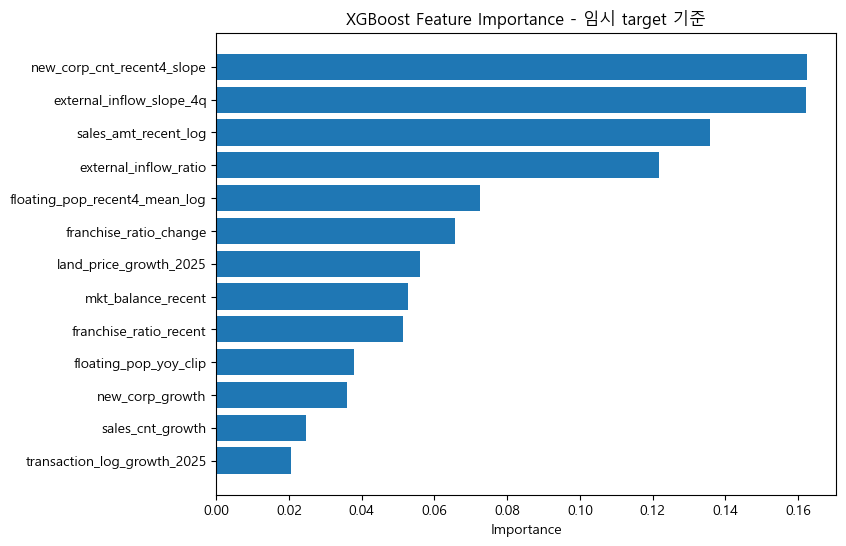

In [30]:
plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance - 임시 target 기준")
plt.xlabel("Importance")
plt.show()

임시 target 기준 XGBoost feature importance를 확인한 결과, `new_corp_cnt_recent4_slope`, `external_inflow_slope_4q`, `sales_amt_recent_log`, `external_inflow_ratio` 등이 상대적으로 높은 중요도를 보였다.

이는 임시 위험군을 구분하는 데 최근 신규기업 증가 추세, 외부유입 증가 추세, 매출 규모, 외부유입 비중이 주요하게 사용되었음을 의미한다.

다만 현재 target은 최종 K-Means 결과가 아닌 임시 규칙 기반 라벨이므로, 해당 중요도는 최종 해석이 아니라 XGBoost 코드 검증 및 변수 반응 확인용으로 해석한다.

In [31]:
# =========================================================
# 임시 위험군/비위험군 변수 평균 비교
# =========================================================

compare_features = [
    "new_corp_cnt_recent4_slope",
    "external_inflow_slope_4q",
    "sales_amt_recent_log",
    "external_inflow_ratio",
    "floating_pop_recent4_mean_log",
    "franchise_ratio_change",
    "land_price_growth_2025",
    "mkt_balance_recent",
    "franchise_ratio_recent",
    "floating_pop_yoy_clip",
    "new_corp_growth",
    "sales_cnt_growth",
    "transaction_log_growth_2025",
]

risk_compare = (
    xgb_df
    .groupby("risk_label_temp")[compare_features]
    .mean()
    .T
    .rename(columns={0: "임시 비위험군 평균", 1: "임시 위험군 평균"})
)

risk_compare["차이_위험군-비위험군"] = (
    risk_compare["임시 위험군 평균"] - risk_compare["임시 비위험군 평균"]
)

display(risk_compare.sort_values("차이_위험군-비위험군", ascending=False))

risk_label_temp,임시 비위험군 평균,임시 위험군 평균,차이_위험군-비위험군
external_inflow_slope_4q,16851.083027,55265.085538,38414.002511
external_inflow_ratio,34.116421,43.574554,9.458133
franchise_ratio_recent,5.283074,7.956428,2.673354
new_corp_cnt_recent4_slope,0.200000,1.938462,1.738462
sales_amt_recent_log,24.226163,25.774936,1.548773
floating_pop_recent4_mean_log,14.236774,15.215462,0.978688
franchise_ratio_change,-0.296831,0.251043,0.547875
land_price_growth_2025,3.207875,3.744772,0.536896
transaction_log_growth_2025,-0.125954,0.313600,0.439555
floating_pop_yoy_clip,0.646713,0.788318,0.141606


| 변수                              | 해석                  |
| ------------------------------- | ------------------- |
| `external_inflow_slope_4q`      | 최근 외부유입 증가 추세가 훨씬 큼 |
| `external_inflow_ratio`         | 외부유입 비중이 높음         |
| `franchise_ratio_recent`        | 프랜차이즈 침투율이 높음       |
| `new_corp_cnt_recent4_slope`    | 최근 신규기업 증가 추세가 높음   |
| `sales_amt_recent_log`          | 매출 규모가 큼            |
| `floating_pop_recent4_mean_log` | 유동인구 규모가 큼          |
| `land_price_growth_2025`        | 공시지가 상승률이 높음        |
| `transaction_log_growth_2025`   | 거래량 변화도 상대적으로 높음    |


In [32]:
import shap
print(shap.__version__)

0.51.0


In [34]:
# =========================================================
# SHAP 분석 - 임시 target 기준
# 주의: 최종 K-Means 라벨이 아니라 risk_label_temp 기준
# =========================================================

import shap
import pandas as pd
import numpy as np

# SHAP explainer 생성
explainer = shap.TreeExplainer(xgb_model)

# SHAP 값 계산
shap_values = explainer.shap_values(X)

print("X shape:", X.shape)
print("SHAP values shape:", np.array(shap_values).shape)

X shape: (50, 13)
SHAP values shape: (50, 13)


In [35]:
# =========================================================
# 평균 절대 SHAP 값 기준 변수 중요도
# =========================================================

shap_importance = pd.DataFrame({
    "feature": xgb_features,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance)

,feature,mean_abs_shap
2,external_inflow_slope_4q,1.577851
8,franchise_ratio_change,0.493763
4,land_price_growth_2025,0.432996
1,external_inflow_ratio,0.408391
12,sales_amt_recent_log,0.377662
11,new_corp_cnt_recent4_slope,0.164171
0,floating_pop_recent4_mean_log,0.149653
7,franchise_ratio_recent,0.128627
6,mkt_balance_recent,0.104827
10,new_corp_growth,0.059860


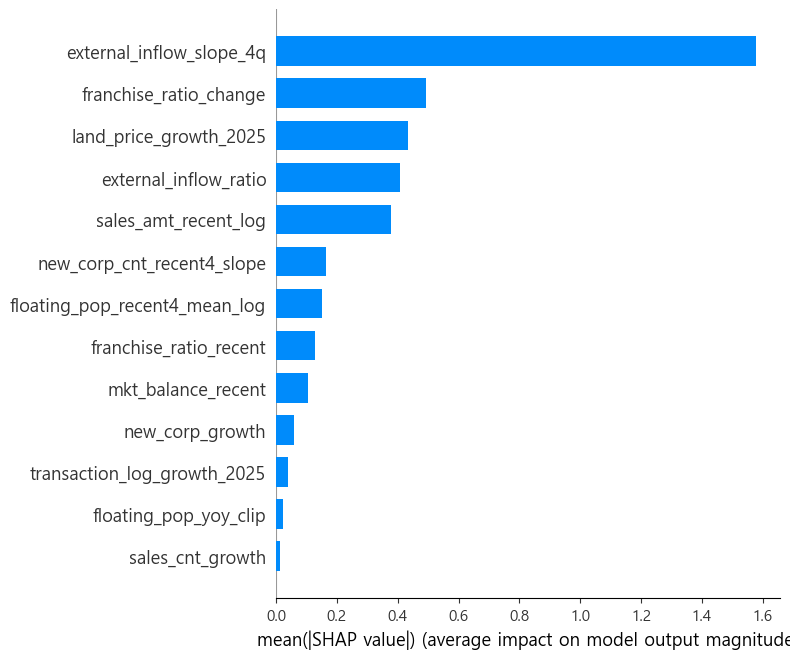

In [36]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    show=True
)

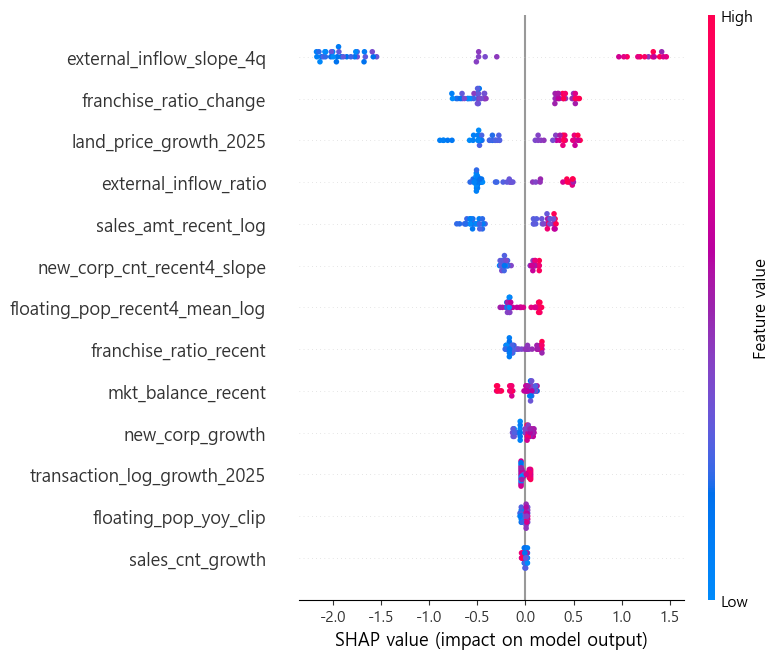

In [37]:
shap.summary_plot(
    shap_values,
    X,
    show=True
)

- 오른쪽으로 갈수록 위험군 1 예측에 기여
- 왼쪽으로 갈수록 비위험군 0 예측에 기여
- 빨간색 = 변수값 높음
- 파란색 = 변수값 낮음

현재 SHAP 분석은 최종 K-Means 라벨이 확정되기 전이므로, 임시 target인 `risk_label_temp`를 기준으로 수행하였다.  
따라서 본 결과는 최종 해석이 아니라 XGBoost 해석 코드 구조를 확인하기 위한 연습용 결과이다.

추후 최종 K-Means 결과에서 위험군 라벨이 확정되면, 동일한 SHAP 분석 코드를 최종 target 기준으로 다시 실행할 예정이다.

# K-menas 결과를 바탕으로 XGboost 실행

In [4]:
BASE_DIR = Path("../data").resolve()

df = pd.read_csv(BASE_DIR / "for_xgboost_file.csv", encoding="utf-8-sig")

print(df.shape)
display(df.head())
display(df["gentrification_risk"].value_counts())

(50, 15)


,gu,adm_dong_cd,adm_dong_nm,land_price_growth_final,mkt_vital_balance,close_rate_recent_final,transaction_growth_final,franchise_ratio_change,new_corp_growth,sales_amt_growth,open_rate_recent_final,floating_pop_growth,external_inflow_growth,cluster_number,gentrification_risk
0,수정구,41131510,신흥1동,0.053756,-0.004179,1.129590,0.866667,0.041131,1.000000,-0.098164,0.990485,-0.086430,0.424755,1,0
1,수정구,41131520,신흥2동,0.053756,-0.000702,1.135723,0.866667,1.316647,0.500000,-0.040493,1.536592,0.459224,0.688518,1,0
2,수정구,41131530,신흥3동,0.053756,-0.000338,0.990797,0.866667,-0.193776,0.000000,0.006949,1.160680,0.032529,0.328898,1,0
3,수정구,41131540,태평1동,0.046877,-0.002679,0.925970,0.483871,-0.921823,1.750000,-0.093449,0.902802,0.030470,0.312026,1,0
4,수정구,41131550,태평2동,0.046877,-0.001200,1.024391,0.483871,-0.022637,-0.666667,0.093938,0.993374,-0.043988,0.377108,1,0


gentrification_risk
0    45
1     5
Name: count, dtype: int64

In [14]:
feature_cols = [
    "land_price_growth_final",
    "mkt_vital_balance",
    "close_rate_recent_final",
    "transaction_growth_final",
    "franchise_ratio_change",
    "new_corp_growth",
    "sales_amt_growth",
    "open_rate_recent_final",
    "floating_pop_growth",
    "external_inflow_growth"
]

X = df[feature_cols].copy()
X = X.fillna(X.median())

y = df["gentrification_risk"].copy()

print("X:", X.shape)
print("y 분포:")
display(y.value_counts())
display(X.isna().sum())

X: (50, 10)
y 분포:


gentrification_risk
0    45
1     5
Name: count, dtype: int64

land_price_growth_final     0
mkt_vital_balance           0
close_rate_recent_final     0
transaction_growth_final    0
franchise_ratio_change      0
new_corp_growth             0
sales_amt_growth            0
open_rate_recent_final      0
floating_pop_growth         0
external_inflow_growth      0
dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"]
))

print(classification_report(y_test, y_pred))

Accuracy: 1.0


,예측 0,예측 1
실제 0,14,0
실제 1,0,1


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00         1

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [17]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

,feature,importance
6,sales_amt_growth,0.285932
4,franchise_ratio_change,0.241445
0,land_price_growth_final,0.123662
9,external_inflow_growth,0.115400
3,transaction_growth_final,0.114014
5,new_corp_growth,0.087572
1,mkt_vital_balance,0.026279
7,open_rate_recent_final,0.005696
2,close_rate_recent_final,0.000000
8,floating_pop_growth,0.000000


In [11]:
import shap

,feature,mean_abs_shap
6,sales_amt_growth,0.497287
4,franchise_ratio_change,0.132808
9,external_inflow_growth,0.010526
5,new_corp_growth,0.010145
0,land_price_growth_final,0.008523
3,transaction_growth_final,0.008323
1,mkt_vital_balance,0.005904
7,open_rate_recent_final,0.003992
2,close_rate_recent_final,0.000000
8,floating_pop_growth,0.000000


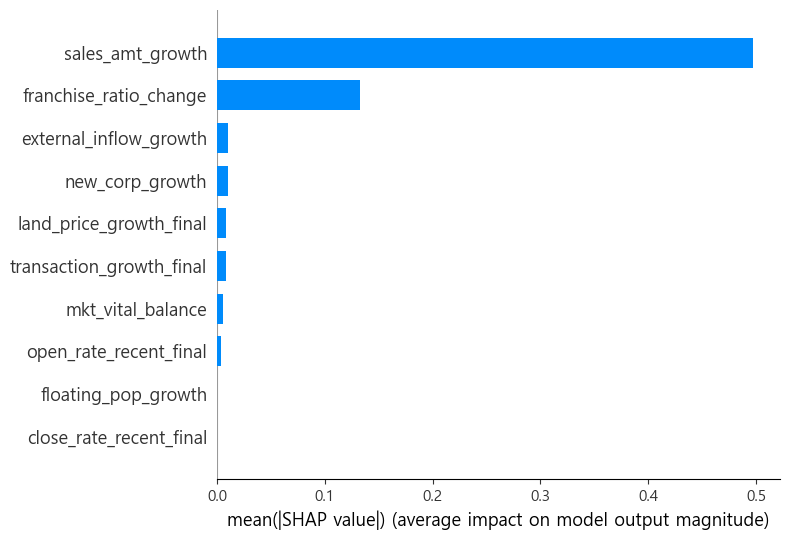

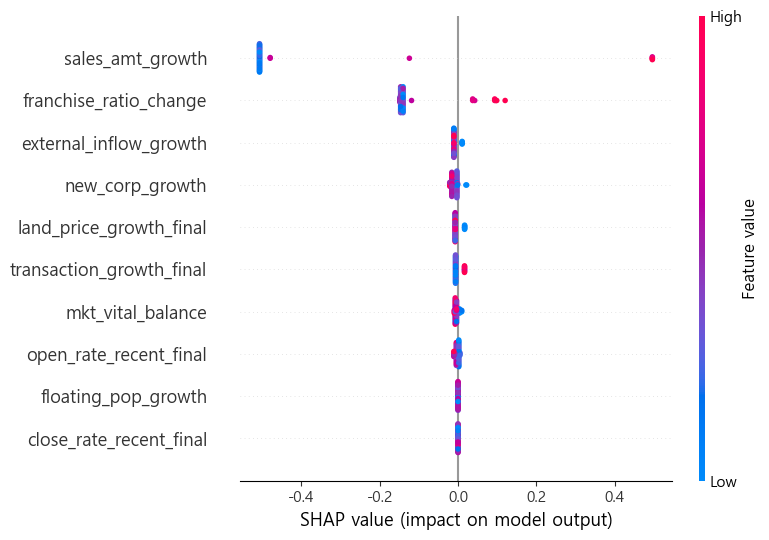

In [18]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance)

shap.summary_plot(shap_values, X, plot_type="bar")
shap.summary_plot(shap_values, X)

팀원이 최종 K-Means 결과를 기반으로 위험군 여부 컬럼인 gentrification_risk를 생성해주었고, 이를 XGBoost의 target으로 사용하였다. 
설명변수는 부동산, 상권, 인구 관련 10개 지표를 사용하였다. 
다만 전체 50개 행정동 중 위험군이 5개로 표본 수가 적고 불균형하기 때문에, 모델 정확도보다는 변수 중요도와 SHAP 분석을 통한 해석에 초점을 두었다.